# Random Forest (Bagging)

- My own implementation
- An ensemble of the CART tree from `../decision_tree`, refactored into `tree.py`
- Goal: tame the overfitting a single deep tree showed by **averaging many decorrelated trees**

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.data import load_data
# The decision tree, refactored into a class — the forest's base learner.
from tree import CARTDecisionTree

In [32]:
# Noisy two-moons data: a curved boundary with enough noise that a single
# deep tree overfits — exactly the weakness a forest fixes.
# noise=0.25 is a deliberate balance: enough to make the tree chase noise
# (leaving a real train/test gap), but not so much that the crescents smear
# into shapeless blobs.
# .to_numpy() rather than .values: Series.values is typed as a union that
# includes ExtensionArray, so type checkers can't narrow it to a plain ndarray.
NOISE = 0.25

df = load_data(n_samples=1000, noise=NOISE, seed=42)
X = df[['feature_1', 'feature_2']].to_numpy()
y = df['label'].to_numpy()

# A fresh, independent sample = honest test set (the tree/forest never trains on it).
test_df = load_data(n_samples=1000, noise=NOISE, seed=7)
X_test = test_df[['feature_1', 'feature_2']].to_numpy()
y_test = test_df['label'].to_numpy()
df.head()

,feature_1,feature_2,label
0,0.183369,0.393655,1
1,0.873694,-0.537605,1
2,1.052720,-0.357384,1
3,0.275748,-0.485594,1
4,-1.140932,-0.003046,0


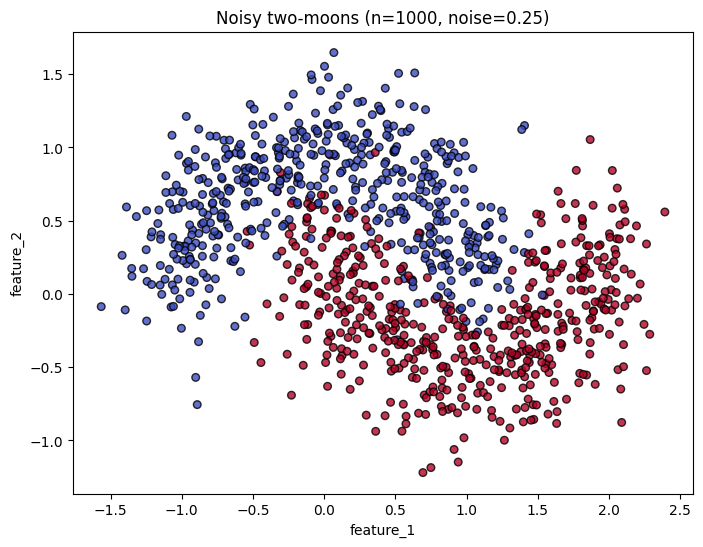

In [33]:
# Two interleaving crescents. The noise smears them into each other near the
# seam — that overlap is the region where a single tree will overfit.
# Title is derived from the data so it can't go stale when the params change.
plt.figure(figsize=(8, 6))
plt.scatter(df['feature_1'], df['feature_2'], c=df['label'], cmap='coolwarm', edgecolor='k', s=30, alpha=0.8)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title(f'Noisy two-moons (n={len(df)}, noise={NOISE})')
plt.show()

## Baseline — a single deep tree

Before building the forest, let's reproduce the overfitting we're trying to cure. A deep single tree memorizes the training set (train accuracy near 1.0) but leaves a gap on the test set. The forest's job is to close that gap.

Note `CARTDecisionTree` is constructed with no `max_features`, which defaults to `None` — meaning every split searches every column. That's the plain decision tree from the previous notebook, unchanged.

In [34]:
single = CARTDecisionTree(max_depth=10).fit(X, y)
print(f"single tree  train acc: {np.mean(single.predict(X) == y):.3f}")
print(f"single tree  test  acc: {np.mean(single.predict(X_test) == y_test):.3f}")

single tree  train acc: 0.992
single tree  test  acc: 0.933


## Step 1 — Bootstrap sampling

Bagging = **B**ootstrap **AGG**regat**ING**. The first half is the bootstrap: instead of training every tree on the *same* data, we give each tree its own random resample of the rows, drawn **with replacement**.

"With replacement" is the key: a bootstrap sample is the same *size* as the original (n rows), but because we can pick the same row more than once, each sample includes roughly **63%** of the unique rows — the rest are duplicated or left out. Every tree therefore sees a slightly different dataset, which is what makes the trees *differ*. Averaging only helps when the trees make different mistakes.

This is the **rows** axis of the forest's randomness. `tree.py` already handles the **columns** axis: `max_features` makes each split search a random subset of features, redrawn at every node.

Because the whole point is that each tree gets a *different* sample, this function must draw fresh randomness each call — so it takes an `rng` (a NumPy `Generator`) that the forest will advance between trees.

In [35]:
def bootstrap_sample(X: np.ndarray, y: np.ndarray, rng: np.random.Generator):
    """
    Draw a bootstrap resample of the data: n rows sampled WITH replacement.

    The returned sample has the same number of rows as the input, but some rows
    appear multiple times and others not at all. X and y must stay aligned —
    row i of the returned X_sample must correspond to row i of y_sample.

    Args:
        X: features, shape (n_samples, n_features).
        y: labels, shape (n_samples,).
        rng: a NumPy Generator (np.random.default_rng(...)) for reproducibility.

    Returns:
        X_sample, y_sample — the resampled features and labels.
    """
    n = X.shape[0]
    idx = rng.integers(n, size=n)
    X_sample = X[idx]
    y_sample = y[idx]
    return X_sample, y_sample

In [36]:
rng = np.random.default_rng(42)
Xs, ys = bootstrap_sample(X, y, rng)
print(f"sample size: {len(Xs)} (expected {len(X)})")
unique_rows = len(np.unique(Xs, axis=0))
print(f"unique rows: {unique_rows} / {len(X)}  (~{unique_rows / len(X):.0%}, expected ~63%)")

sample size: 1000 (expected 1000)
unique rows: 637 / 1000  (~64%, expected ~63%)


## Step 2 — Growing the forest

Both sources of randomness now exist, one per axis of the data:

| | Rows | Columns |
|---|---|---|
| Per tree | `bootstrap_sample` — resample **with** replacement | — |
| Per node | (follows from the splits above) | `max_features` — random subset **without** replacement |

So the forest has nothing left to invent. It just **assembles**: for each of `n_trees`, draw a bootstrap sample and fit a `CARTDecisionTree` on it. That loop *is* bagging.

Two details the scaffold handles:

- **The √ rule.** `max_features='sqrt'` resolves to `max(1, int(sqrt(n_features)))` — but only at `fit` time, since `n_features` doesn't exist until the data arrives. The resolved value is stored as `max_features_` (trailing underscore = "computed during fit"), which is the same convention as `tree_`.
- **One shared generator.** Every tree receives the forest's `self.rng` rather than a fixed seed. If each tree got the *same* seed, every tree would draw the *same* feature sequence and the subsampling would be pointless. Sharing one advancing generator is what keeps them different.

In [41]:
class RandomForest:
    """
    A bagged ensemble of CART decision trees.

    Each tree is grown on its own bootstrap resample of the rows, and (via
    max_features) each split within a tree searches only a random subset of the
    columns. Those two independent sources of randomness decorrelate the trees;
    averaging decorrelated trees is what reduces variance.

    Args:
        n_trees: how many trees to grow.
        max_depth: max depth of each tree. Individual trees are allowed to
            overfit — bagging is what cleans that up, so this runs deeper than
            you'd risk with a single tree.
        min_samples_split: don't split a node with fewer than this many samples.
        max_features: columns each split may search. 'sqrt' -> sqrt(n_features)
            (the random forest default), an int -> that many, None -> all
            columns (which makes this plain bagging, with no column randomness).
        random_state: seed for reproducibility.
    """

    def __init__(self, n_trees: int = 100, 
                 max_depth: int = 8, 
                 min_samples_split: int = 2,
                 max_features: str | int | None = 'sqrt', 
                 random_state: int | None = None):
        
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees_ = []
        self.max_features_ = None

    def _resolve_max_features(self, n_features: int) -> int | None:
        """
        Turn the max_features *policy* into a concrete column count.

        Can only run once the data is known — 'sqrt' is a promise to compute
        this later, which is why it resolves here in fit rather than __init__.
        """
        if self.max_features is None:
            return None
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_features)))
        return max(1, min(int(self.max_features), n_features))

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Grow the forest: one tree per bootstrap resample of the training data.

        Args:
            X: features, shape (n_samples, n_features).
            y: labels, shape (n_samples,).

        Returns:
            self — so calls can chain, matching CARTDecisionTree.fit.
        """
        self.max_features_ = self._resolve_max_features(X.shape[1])
        self.trees_ = []

        for _ in range(self.n_trees):
            X_sample, y_sample = bootstrap_sample(X, y, self.rng)

            tree = CARTDecisionTree(max_depth = self.max_depth, min_samples_split = self.min_samples_split, max_features = self.max_features_, random_state = self.rng)
            tree.fit(X_sample, y_sample)

            self.trees_.append(tree)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict each sample's label by majority vote across all trees.

        This is the "aggregating" in bootstrap aggregating: the step where many
        noisy, individually-overfit trees collapse into one stable answer. Each
        tree votes on every sample; the label with the most votes wins.

        Args:
            X: features, shape (n_samples, n_features).

        Returns:
            1D array of predicted labels, shape (n_samples,).
        """
        # Every tree predicts every sample -> shape (n_trees, n_samples).
        # Column j therefore holds all n_trees votes for sample j.
        all_preds = np.array([tree.predict(X) for tree in self.trees_])


        def majority_vote(column):
            values, counts = np.unique(column, return_counts=True)
            # argmax gives the POSITION of the largest count, not the count itself.
            # Indexing `values` with that position turns "entry 1 won the tally"
            # back into "the winning label is 1".
            return values[np.argmax(counts)]

        result = np.array([])
        for column in all_preds.T:
            result = np.append(result, majority_vote(column))

        return result

## Step 3 — Aggregating the votes

The trees are grown and they genuinely differ. All that's left is to combine them.

Each tree predicts every sample, giving an `(n_trees, n_samples)` grid of votes — column `j` is every tree's opinion about sample `j`. The forest's answer for sample `j` is simply the **most common value in column `j`**.

That's the entire aggregation step, and it's where the variance reduction actually happens. Any single tree is confidently wrong about *some* region of the noisy seam, but each tree is wrong about a *different* region — because each saw different rows and different columns. Majority voting keeps what the trees agree on (the real signal) and discards what only a minority believe (the noise each one memorized).

The comparison below is deliberately **depth-matched**: the same `max_depth` for the lone tree and for every tree in the forest. That isolates the one variable we care about — averaging — rather than confounding it with tree size.

In [42]:
DEPTH = 10  # same depth for the lone tree and for every tree in the forest

lone = CARTDecisionTree(max_depth=DEPTH).fit(X, y)
wood = RandomForest(n_trees=100, max_depth=DEPTH, random_state=42).fit(X, y)

preds = wood.predict(X_test)
print(f"predict returned shape {preds.shape} (want ({len(y_test)},) — one label per sample)")
print()

for name, model in [("single tree", lone), ("forest (100)", wood)]:
    train = np.mean(model.predict(X) == y)
    test = np.mean(model.predict(X_test) == y_test)
    print(f"{name:13} train {train:.3f}   test {test:.3f}   gap {train - test:.3f}")

predict returned shape (1000,) (want (1000,) — one label per sample)

single tree   train 0.992   test 0.933   gap 0.059
forest (100)  train 0.998   test 0.944   gap 0.054


## Step 4 — Seeing the variance reduction

The numbers say the forest generalizes better. The picture says *why*.

We classify a fine grid of points and shade each one by its predicted class, which paints the regions each model carved out. Watch for:

- **The single tree** produces hard, blocky, axis-aligned regions, with isolated islands stranded deep in the opposing class. Each island is a handful of noisy training points the tree bent over backwards to memorize. That memorization is the 0.104 train/test gap, made visible.
- **The forest** produces a smoother, rounder boundary that mostly ignores those stragglers. No individual tree is smooth — every tree is just as blocky as the one on the left. But the trees disagree about *where* to put their blocks, so voting averages a hundred jagged boundaries into a rounded one, and an island only survives if a majority of trees independently invent it.

The forest never learned to draw curves. It approximates one by **stacking disagreements**.

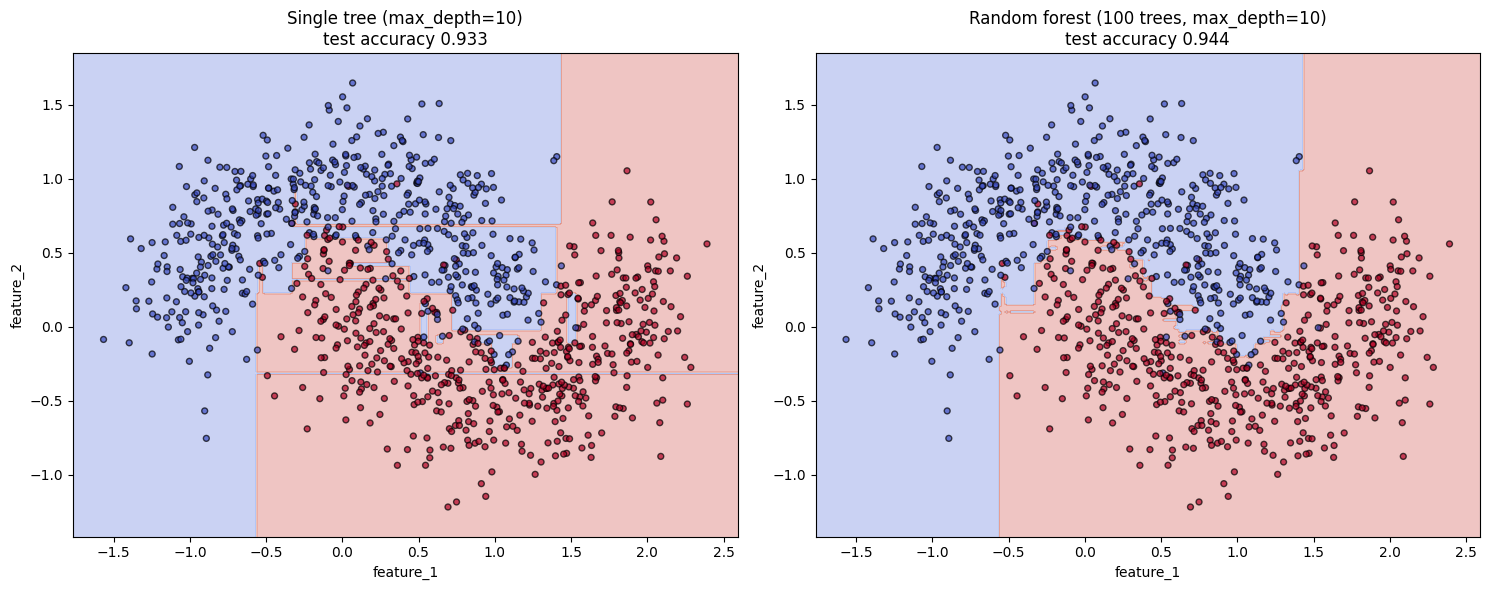

In [44]:
def plot_boundary(ax, model, title, resolution=300, pad=0.2):
    """
    Shade a grid by predicted class to reveal the regions a model carved out.

    Args:
        ax: matplotlib axes to draw on.
        model: any fitted estimator with a .predict(X) method — the plot doesn't
            care whether it's one tree or a hundred, which is exactly why
            CARTDecisionTree and RandomForest sharing an interface is useful.
        title: axes title.
        resolution: grid points per side. 300x300 = 90k predictions (~5.5s for
            the forest, since predict traverses every tree in Python).
        pad: margin around the data, in data units.
    """
    # Grid bounds come from the data. The moons live outside the unit square
    # (x roughly -1.7..2.5), so unlike the XOR notebook we can't hardcode
    # linspace(0, 1) — that would silently plot a crop of the real boundary.
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))

    # ravel -> (n_points, 2) so predict sees a normal feature matrix,
    # then reshape the answers back into the grid's 2D layout for contourf.
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.30, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=18, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('feature_1')
    ax.set_ylabel('feature_2')


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tree_acc = np.mean(lone.predict(X_test) == y_test)
forest_acc = np.mean(wood.predict(X_test) == y_test)

plot_boundary(axes[0], lone, f"Single tree (max_depth={DEPTH})\ntest accuracy {tree_acc:.3f}")
plot_boundary(axes[1], wood, f"Random forest ({wood.n_trees} trees, max_depth={DEPTH})\ntest accuracy {forest_acc:.3f}")

plt.tight_layout()
plt.show()